In [3]:
#!/usr/bin/env python3
"""
This script contains the cortical data used in manuscript 
NEUROTRANSMITTER TRANSPORTER/RECEPTOR CO-EXPRESSION SHARES ORGANIZATIONAL TRAITS WITH BRAIN STRUCTURE AND FUNCTION
https://doi.org/10.1101/2022.08.26.505274

Original code: https://github.com/CNG-LAB/cngopen/tree/main/receptor_similarity/code

Developed by Benjamin Hänisch

Adapted: Carlos Estevez-Fraga
"""

'\nAuthor: Benjamin Hänish\nCerebral chemoarchitecture shares organizational traits with brain structure and function\nElife. 2023 Jul 13;12:e83843. doi: 10.7554/eLife.83843.\n\nOriginal code: https://github.com/CNG-LAB/cngopen/tree/main/receptor_similarity/code\n\nAdapted: Carlos Estevez Fraga\n'

In [4]:
import enigmatoolbox
from enigmatoolbox import datasets
from enigmatoolbox.utils.parcellation import parcel_to_surface
import nilearn
from brainspace.null_models import SpinPermutations
import matplotlib.pyplot as plt
import plotly.express as px
from mn_funcs import spin, schaefer_to_surf
from plotly.graph_objs import *
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import nibabel as nib
from nilearn.input_data import NiftiLabelsMasker
import re
import os
from nilearn import surface

In [11]:
parcels = 100
input_path = '/Users/charlie/Desktop/my_projects/neurotransmitter/github/data/'
res_p = '/Users/charlie/Desktop/my_projects/neurotransmitter/github/results/'

rc_g1 = np.load(input_path + 'rc_g1_100.npy')
rc_g2 = np.load(input_path + 'rc_g2_100.npy')
rc_g3 = np.load(input_path + 'rc_g3_100.npy')



In [8]:
#NODE
disorders = ['node_track', 'node_trackon', 'node_yas']
d = {}


# Read the CSV file
data=pd.read_csv('/Users/charlie/Desktop/my_projects/neurotransmitter/github/data/mHD/cohens_d_right_transp.csv', header = None)
# Remove the first row
data = data.iloc[1:]
# Remove the first two columns
data = data.iloc[:, 1:]
# Reset the index
data = data.reset_index(drop=True)
data=data.values.flatten()
ct_surf = parcel_to_surface(data, target_lab='aparc_fsa5')
d['node_track']=ct_surf 



# Read the CSV file
data=pd.read_csv('/Users/charlie/Desktop/my_projects/neurotransmitter/github/data/latepreHD/cohens_d_right_transp.csv', header = None)
# Remove the first row
data = data.iloc[1:]
# Remove the first two columns
data = data.iloc[:, 1:]
# Reset the index
data = data.reset_index(drop=True)
data=data.values.flatten()
ct_surf = parcel_to_surface(data, target_lab='aparc_fsa5')
d['node_trackon']=ct_surf 

# Read the CSV file
data=pd.read_csv('/Users/charlie/Desktop/my_projects/neurotransmitter/github/data/earlypreHD/cohens_d_right_transp.csv', header = None)
# Remove the first row
data = data.iloc[1:]
# Remove the first two columns
data = data.iloc[:, 1:]
# Reset the index
data = data.reset_index(drop=True)
data=data.values.flatten()
ct_surf = parcel_to_surface(data, target_lab='aparc_fsa5')
d['node_yas']=ct_surf 



In [9]:
#Change number permutations
fsavg = nilearn.datasets.fetch_surf_fsaverage('fsaverage5')
sphere_lh_fs = surface.load_surf_mesh(fsavg['sphere_left'])[0]
sphere_rh_fs = surface.load_surf_mesh(fsavg['sphere_right'])[0]
sp_fs = SpinPermutations(n_rep=1000, random_state=0)
sp_fs.fit(sphere_lh_fs, points_rh=sphere_rh_fs)


SpinPermutations(n_rep=1000, random_state=0)

In [12]:
def permute(inp):
    left = inp[:10242]
    right = inp[10242:]
    return np.hstack(sp_fs.randomize(left, right))

g1 = schaefer_to_surf(parcels, rc_g1)
g2 = schaefer_to_surf(parcels, rc_g2)
g3 = schaefer_to_surf(parcels, rc_g3)

In [13]:
enig_g1_spin = {}
enig_g2_spin = {}
enig_g3_spin = {}
select = ['node_track', 'node_trackon', 'node_yas']

for key, val in d.items():
    if key in select:
        print(key)
        permuted = permute(val)
        enig_g1_spin[key] = spin(g1, val, permuted)
        enig_g2_spin[key] = spin(g2, val, permuted)
        enig_g3_spin[key] = spin(g3, val, permuted)

node_track
node_trackon
node_yas


In [14]:
def plot_corr(inp, fname):
    enigma_keys = {'mHD': inp['node_track'],
                   'Late preHD': inp['node_trackon'],
                   'Early preHD': inp['node_yas']}
    plot = pd.DataFrame.from_dict(enigma_keys, orient='index')
    plot.columns = ['r', 'p_vgm']
    plot.sort_values(by='r', inplace=True)
    fig, ax = plt.subplots(1, figsize=[11, 12])
    color = ['green' if x > 0.05 else 'green' for x in plot['p_vgm']]
    ax.barh(range(len(plot)), plot['r'], color=color)
    ax.set_yticks(range(0, len(plot)))
    ax.set_yticklabels(plot.index, fontsize=32)
    ax.set_xlabel("spearman's r", fontsize=32)
    ax.tick_params(labelsize=32)
    plt.xlim([-0.60, 0.60])
    plt.tight_layout()
    fig.savefig(res_p + fname)
    return

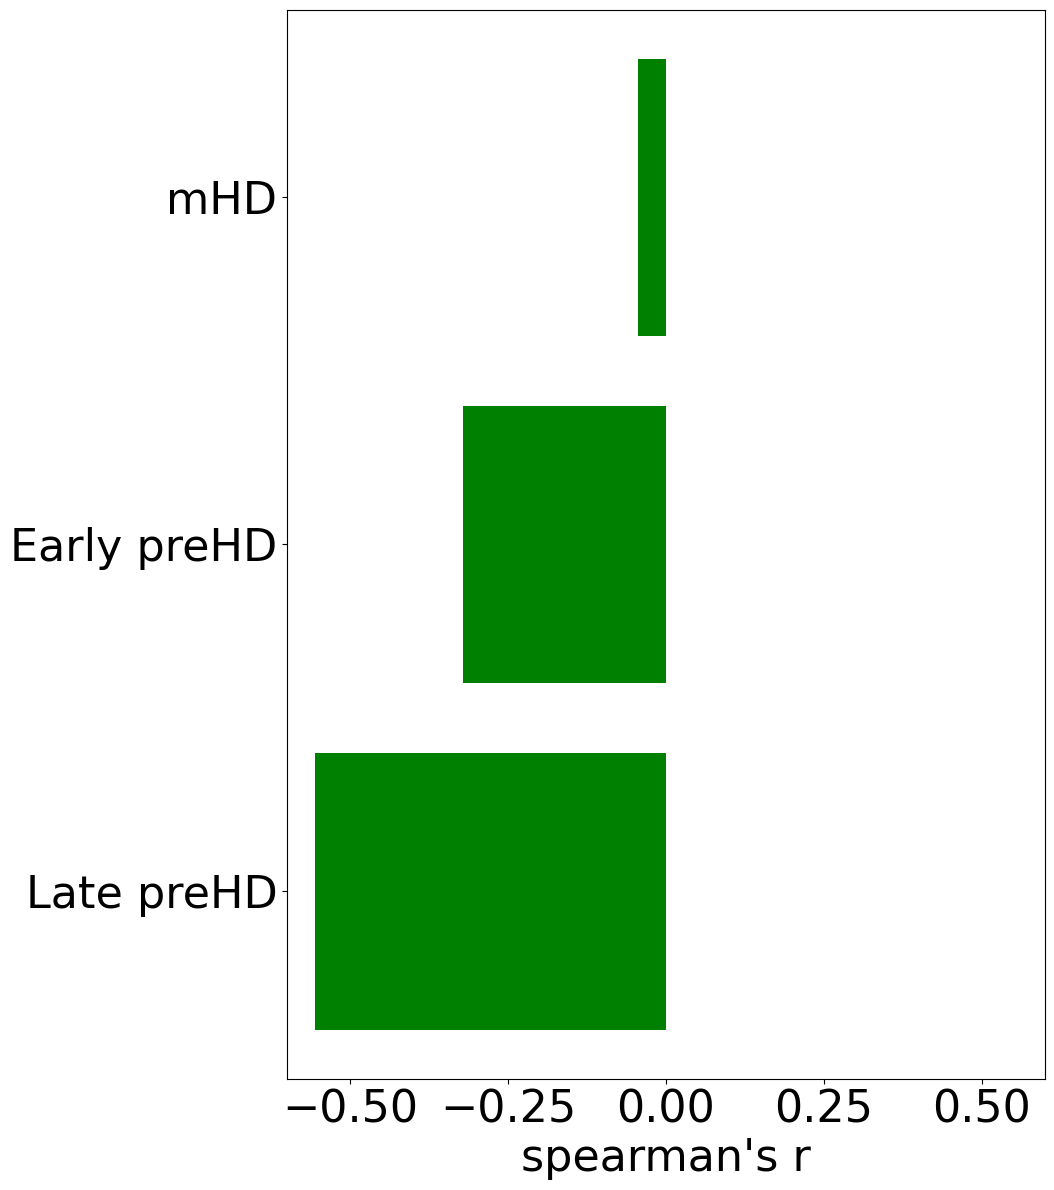

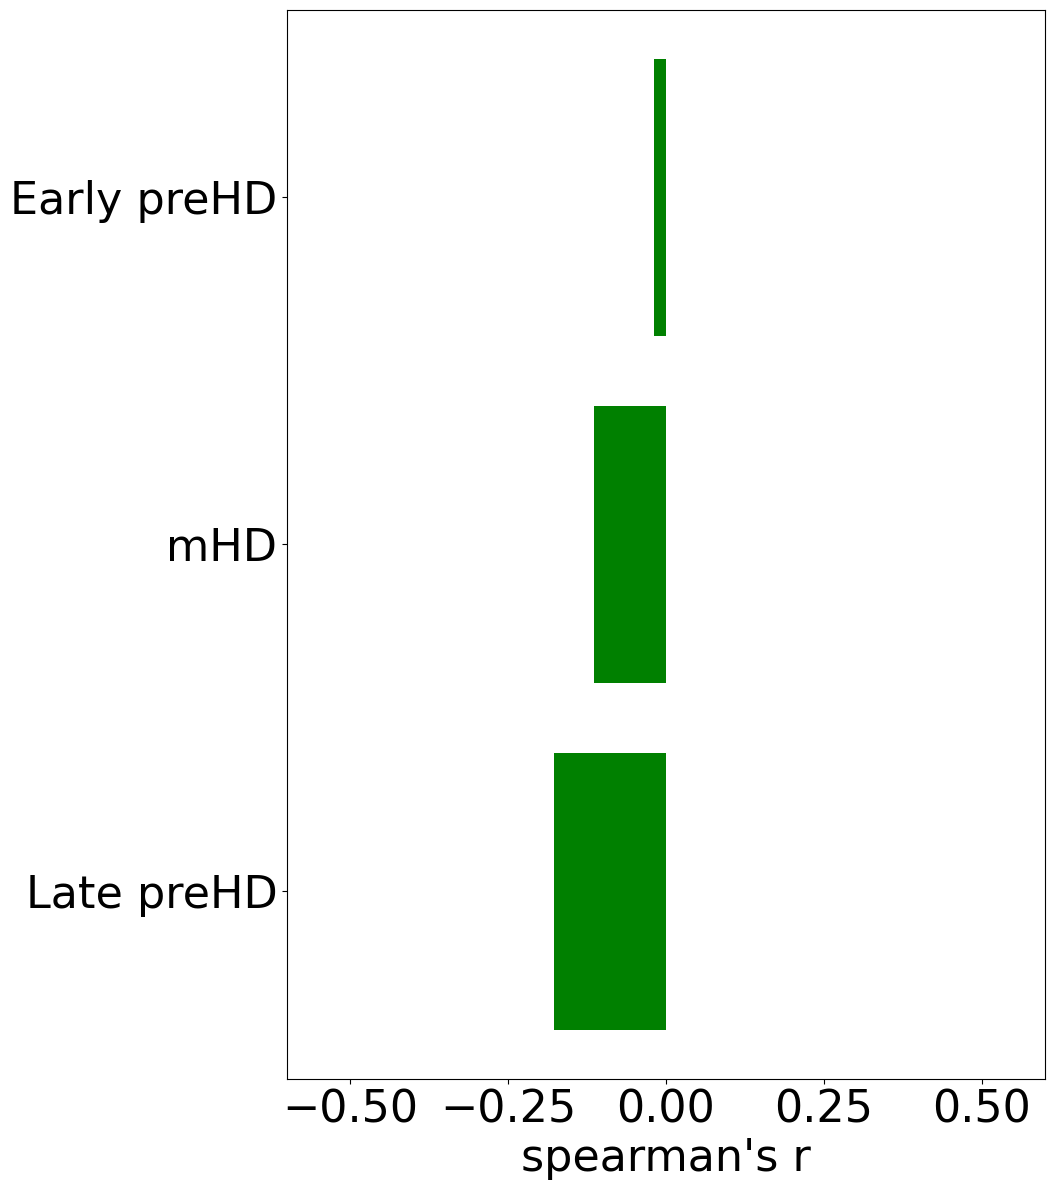

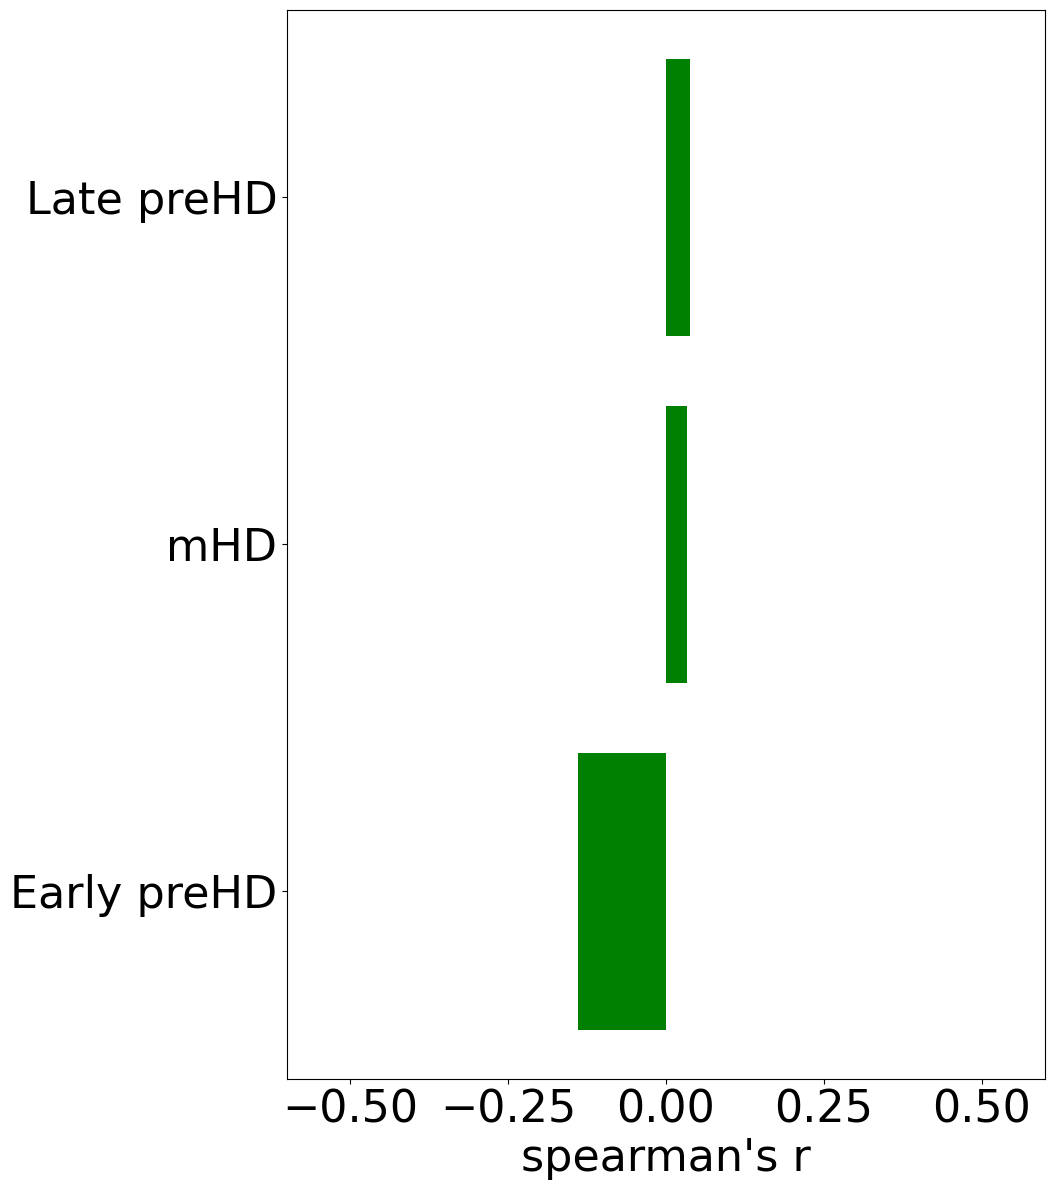

In [15]:
plot_corr(enig_g1_spin, 'rc_g1_mind_node_green.png')
plot_corr(enig_g2_spin, 'rc_g2_mind_node_green.png')
plot_corr(enig_g3_spin, 'rc_g3_mind_node_green.png')
